# # Customer Lifetime Value Model
#
# This notebook-style script generates synthetic Day 0–7 user data, trains a
# separate D180 LTV model for each product, and compares campaign performance.
# Run the file from any working directory with `python notebooks/cel_ltv_model.py`.



In [31]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold, cross_validate, cross_val_predict, train_test_split
from sklearn.pipeline import make_pipeline

# Project paths
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Fixed seed so the synthetic dataset is reproducible.
rng = np.random.default_rng(42)


# ## 2. Generate synthetic user data

The synthetic dataset contains only general Day-7 engagement, retention/recency, social behaviour, and product-specific monetisation signals. No game-specific metrics are used. CAC is retained only for downstream campaign economics and ROAS; it is not an ML feature.


In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_data(n=12000):
    """
    Synthetic Day-0 to Day-7 dataset for the CEL Analyst Assignment.

    
    CAC is a campaign-level economic measure, not an ML feature.
    """

    product = rng.choice(["subscription", "ad_supported"], n)
    campaign = rng.choice(["Campaign_A", "Campaign_B"], n)

    # Campaign-l
    # evel CAC: used for ROAS, NOT as a model feature.
    campaign_cac = {"Campaign_A": 90.0, "Campaign_B": 105.0}
    cac = pd.Series(campaign).map(campaign_cac).to_numpy()

    # Hidden variable used only to generate realistic synthetic outcomes.
    # It is deliberately excluded from the model to avoid leakage.
    quality = rng.normal(0, 1, n)

    # -----------------------------
    # Engagement
    # -----------------------------
    active_days_7 = np.clip(
        np.rint(
            3.2
            + 0.9 * quality
            + np.where(campaign == "Campaign_A", -0.25, 0.25)
            + rng.normal(0, 1.0, n)
        ), 1, 7
    ).astype(int)

    sessions_7 = np.clip(
        np.rint(
            4.5
            + 2.0 * quality
            + 0.95 * active_days_7
            + np.where(campaign == "Campaign_A", 0.7, 0)
            + rng.normal(0, 2.4, n)
        ), 1, 40
    ).astype(int)

    avg_session_min_7 = np.clip(
        7 + 2.1 * quality + 0.55 * active_days_7
        + rng.normal(0, 2.4, n),
        2, 30
    )

    sessions_per_active_day_7 = sessions_7 / np.maximum(active_days_7, 1)

    # -----------------------------
    # Retention / recency
    # -----------------------------
    d1_retained = (
        rng.random(n)
        < sigmoid(-0.5 + 0.65 * quality + 0.18 * sessions_7)
    ).astype(int)

    d3_retained = (
        rng.random(n)
        < sigmoid(-1.1 + 0.55 * quality + 0.22 * active_days_7)
    ).astype(int)

    d7_retained = (active_days_7 >= 5).astype(int)

    last_active_day_7 = np.clip(
        np.rint(
            2.8
            + 1.9 * quality
            + 0.55 * active_days_7
            + rng.normal(0, 1.5, n)
        ), 0, 7
    ).astype(int)

    days_since_last_active_7 = 7 - last_active_day_7

    early_sessions = np.maximum(
        1, np.rint(sessions_7 * rng.uniform(0.30, 0.65, n)).astype(int)
    )
    late_sessions = np.maximum(0, sessions_7 - early_sessions)
    session_momentum_7 = late_sessions / np.maximum(early_sessions, 1)

    median_gap_hours_7 = np.clip(
        48
        - 4.0 * quality
        - 1.8 * sessions_per_active_day_7
        + rng.normal(0, 7, n),
        1, 96
    )

    # -----------------------------
    # Subscription monetisation
    # -----------------------------
    engagement_score = (
        0.40 * active_days_7 / 7
        + 0.35 * np.minimum(sessions_7 / 20, 1)
        + 0.25 * np.minimum(avg_session_min_7 / 20, 1)
    )

    trial_started_d7 = (
        (product == "subscription")
        & (
            rng.random(n)
            < sigmoid(
                -1.1
                + 2.3 * engagement_score
                + 0.75 * quality
                + np.where(campaign == "Campaign_A", -0.20, 0.20)
            )
        )
    ).astype(int)

    subscription_started_d7 = (
        (product == "subscription")
        & (
            rng.random(n)
            < sigmoid(
                -2.0
                + 2.8 * engagement_score
                + 1.15 * trial_started_d7
                + 0.65 * quality
            )
        )
    ).astype(int)

    days_to_trial = np.where(
        trial_started_d7 == 1,
        np.clip(
            np.rint(
                5 - 2.0 * quality
                - 0.6 * engagement_score
                + rng.normal(0, 1.2, n)
            ), 1, 7
        ),
        np.nan
    )

    # -----------------------------
    # Ad-supported monetisation
    # -----------------------------
    ad_impressions_7 = np.where(
        product == "ad_supported",
        np.clip(
            np.rint(
                5
                + 3.1 * sessions_7
                + 2.5 * quality
                + rng.normal(0, 7, n)
            ), 0, 220
        ),
        0
    ).astype(int)

    ad_views_7 = np.where(
        product == "ad_supported",
        np.clip(
            np.rint(0.72 * ad_impressions_7 + rng.normal(0, 4, n)),
            0, None
        ),
        0
    ).astype(int)

    rewarded_ads_watched_7 = np.where(
        product == "ad_supported",
        np.clip(
            np.rint(
                0.22 * ad_impressions_7
                + 2.0 * quality
                + rng.normal(0, 4, n)
            ), 0, None
        ),
        0
    ).astype(int)

    ad_view_rate_7 = ad_views_7 / np.maximum(ad_impressions_7, 1)
    rewarded_ad_rate_7 = (
        rewarded_ads_watched_7 / np.maximum(ad_impressions_7, 1)
    )

    # -----------------------------
    # General social / referral behaviour
    # -----------------------------
    social_actions_7 = np.clip(
        np.rint(
            0.3
            + 0.7 * quality
            + 0.10 * sessions_7
            + rng.normal(0, 1.2, n)
        ), 0, 20
    ).astype(int)

    # -----------------------------
    # Future target: D180 LTV
    # -----------------------------
    subscription_ltv = (
        20
        + 135 * subscription_started_d7
        + 35 * trial_started_d7
        + 24 * active_days_7
        + 2.8 * sessions_7
        + 7.0 * avg_session_min_7
        + 18 * d7_retained
        + 25 * quality
    )

    ad_supported_ltv = (
        10
        + 0.85 * ad_impressions_7
        + 0.38 * ad_views_7
        + 1.10 * rewarded_ads_watched_7
        + 16 * active_days_7
        + 2.6 * sessions_7
        + 4.5 * avg_session_min_7
        + 14 * d7_retained
        + 18 * quality
    )

    ltv = np.where(
        product == "subscription",
        subscription_ltv,
        ad_supported_ltv
    )

    # Campaign effect creates a useful D7-vs-D180 comparison scenario.
    ltv += np.where(campaign == "Campaign_A", 10, 30)

    noise_scale = np.where(product == "subscription", 38, 20)
    ltv = np.clip(
        ltv + rng.normal(0, noise_scale, n),
        0, None
    )

    return pd.DataFrame({
        "user_id": np.arange(1, n + 1),
        "product": product,
        "campaign": campaign,

        # Economics only; excluded from ML.
        "cac": cac,

        # General Day-7 features.
        "active_days_7": active_days_7,
        "sessions_7": sessions_7,
        "avg_session_min_7": avg_session_min_7,
        "sessions_per_active_day_7": sessions_per_active_day_7,

        # Retention / recency.
        "d1_retained": d1_retained,
        "d3_retained": d3_retained,
        "d7_retained": d7_retained,
        "last_active_day_7": last_active_day_7,
        "days_since_last_active_7": days_since_last_active_7,
        "session_momentum_7": session_momentum_7,
        "median_gap_hours_7": median_gap_hours_7,

        # Subscription-specific.
        "trial_started_d7": trial_started_d7,
        "subscription_started_d7": subscription_started_d7,
        "days_to_trial": days_to_trial,

        # Ad-supported-specific.
        "ad_impressions_7": ad_impressions_7,
        "ad_views_7": ad_views_7,
        "rewarded_ads_watched_7": rewarded_ads_watched_7,
        "ad_view_rate_7": ad_view_rate_7,
        "rewarded_ad_rate_7": rewarded_ad_rate_7,

        # General behavioural signal.
        "social_actions_7": social_actions_7,

        # Future target.
        "d180_ltv": ltv,
    })


df = make_data()
df.to_csv(DATA_DIR / "synthetic_users.csv", index=False)


## 3. Exploratory Data Analysis (EDA)

EDA is performed before modeling to validate the synthetic dataset, inspect Day-7 signal distributions, understand product/campaign differences, and identify candidate relationships with D180 LTV.


### 1. Data quality and structure


In [33]:
print("Missing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing_values"))
print("Duplicate rows:", df.duplicated().sum())
display(df.describe().T)


Missing values:


,missing_values
days_to_trial,9054
user_id,0
session_momentum_7,0
social_actions_7,0
rewarded_ad_rate_7,0
ad_view_rate_7,0
rewarded_ads_watched_7,0
ad_views_7,0
ad_impressions_7,0
subscription_started_d7,0


Duplicate rows: 0


,count,mean,std,min,25%,50%,75%,max
user_id,12000.0,6000.500000,3464.245950,1.000000,3000.750000,6000.500000,9000.250000,12000.000000
cac,12000.0,97.482500,7.500292,90.000000,90.000000,90.000000,105.000000,105.000000
active_days_7,12000.0,3.255000,1.352945,1.000000,2.000000,3.000000,4.000000,7.000000
sessions_7,12000.0,8.004917,3.736918,1.000000,5.000000,8.000000,11.000000,22.000000
avg_session_min_7,12000.0,8.848267,3.471309,2.000000,6.391216,8.843347,11.237448,21.207436
sessions_per_active_day_7,12000.0,2.631903,1.299535,0.200000,2.000000,2.500000,3.000000,14.000000
d1_retained,12000.0,0.674083,0.468736,0.000000,0.000000,1.000000,1.000000,1.000000
d3_retained,12000.0,0.410500,0.491945,0.000000,0.000000,0.000000,1.000000,1.000000
d7_retained,12000.0,0.180167,0.384342,0.000000,0.000000,0.000000,0.000000,1.000000
last_active_day_7,12000.0,4.351333,2.257282,0.000000,3.000000,5.000000,7.000000,7.000000


### 2. Product and campaign mix


In [34]:
display(df["product"].value_counts().to_frame("users"))
display(df["campaign"].value_counts().to_frame("users"))
display(df.groupby("campaign")["cac"].mean().to_frame("avg_cac"))


,users
product,
subscription,6033
ad_supported,5967


,users
campaign,
Campaign_A,6014
Campaign_B,5986


,avg_cac
campaign,
Campaign_A,90.0
Campaign_B,105.0


### 3. Distribution of key Day-7 signals


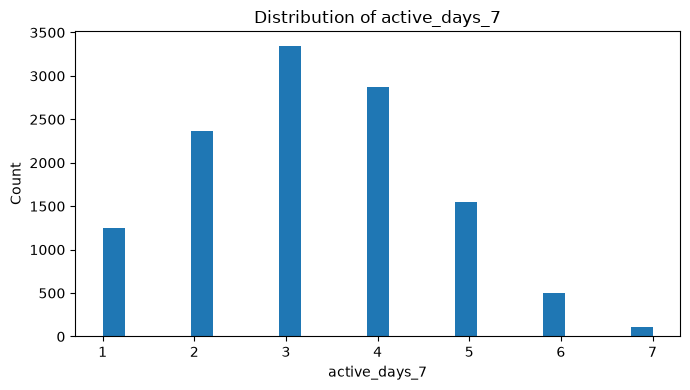

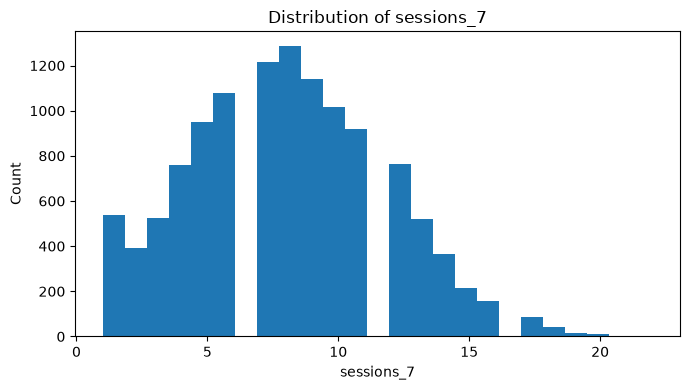

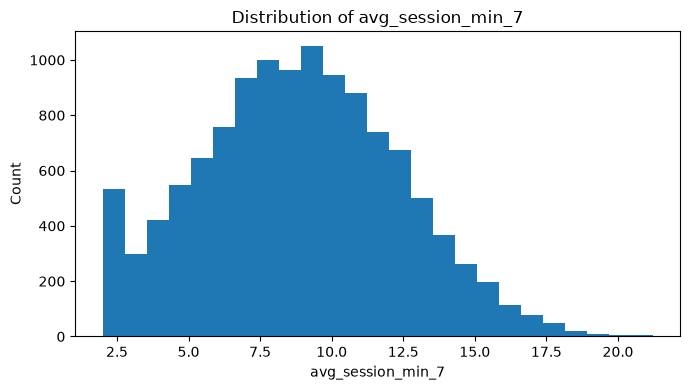

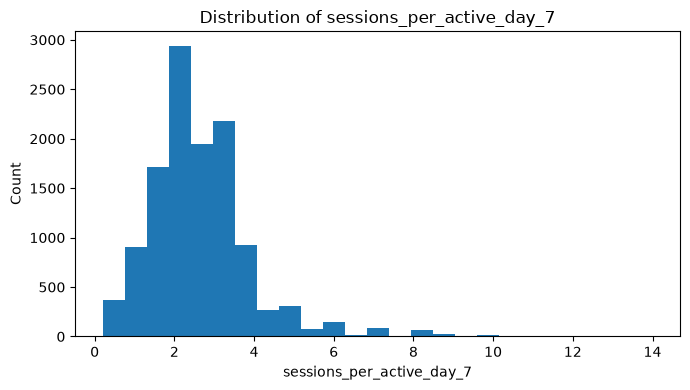

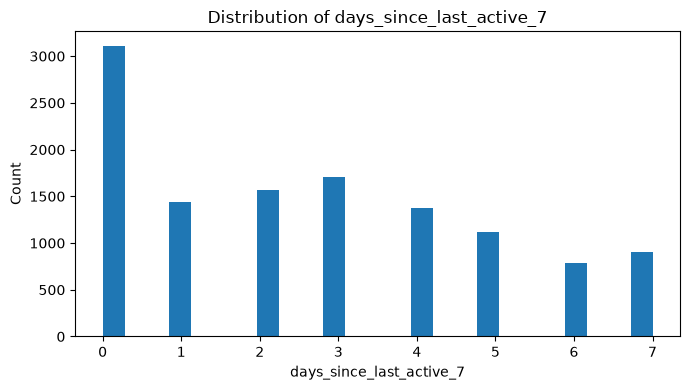

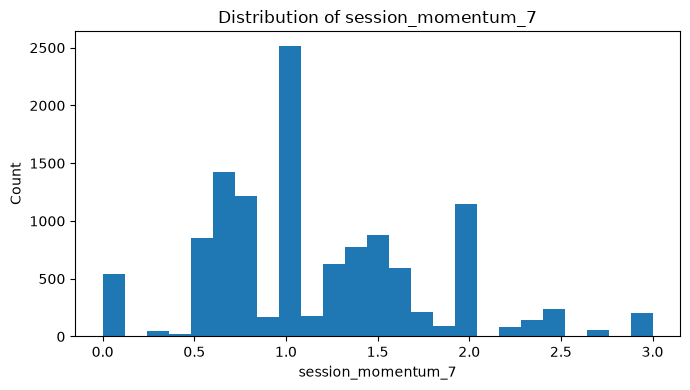

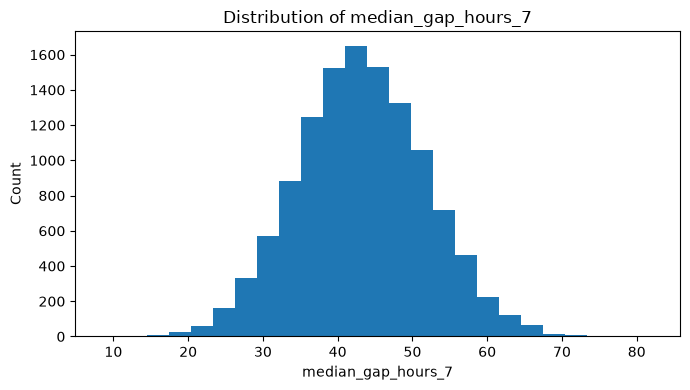

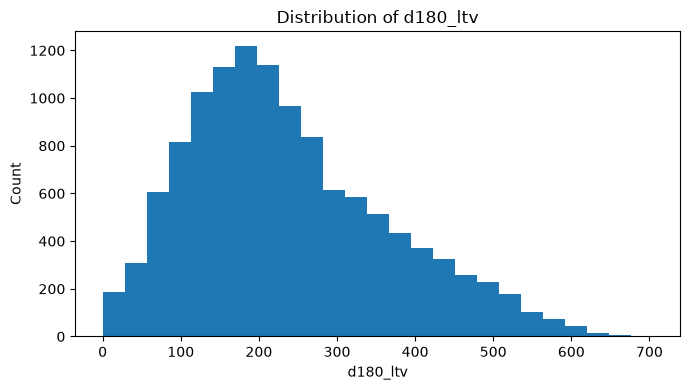

In [35]:
plot_features = [
    "active_days_7", "sessions_7", "avg_session_min_7",
    "sessions_per_active_day_7", "days_since_last_active_7",
    "session_momentum_7", "median_gap_hours_7", "d180_ltv"
]

for col in plot_features:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=25)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


### 4. Retention and monetisation behaviour


In [ ]:
retention_cols = ["d1_retained", "d3_retained", "d7_retained"]
display(df[retention_cols].mean().mul(100).to_frame("retention_percent"))
 
subscription_df = df[df["product"] == "subscription"]
ad_df = df[df["product"] == "ad_supported"]

print("Subscription metrics (%):")
display(subscription_df[["trial_started_d7", "subscription_started_d7"]].mean().mul(100).to_frame("percent"))

print("Ad-supported metrics:")
display(ad_df[[
    "ad_impressions_7", "ad_views_7", "rewarded_ads_watched_7",
    "ad_view_rate_7", "rewarded_ad_rate_7"
]].describe().T)


,retention_percent
d1_retained,67.408333
d3_retained,41.050000
d7_retained,18.016667


Subscription metrics (%):


,percent
trial_started_d7,48.831427
subscription_started_d7,46.345102


Ad-supported metrics:


,count,mean,std,min,25%,50%,75%,max
ad_impressions_7,5967.0,29.976370,15.028499,0.0,19.000,30.000000,40.000000,81.0
ad_views_7,5967.0,21.714262,11.445287,0.0,13.000,21.000000,29.000000,65.0
rewarded_ads_watched_7,5967.0,7.132898,5.657915,0.0,2.000,7.000000,11.000000,32.0
ad_view_rate_7,5967.0,0.756012,0.507849,0.0,0.625,0.722222,0.818182,12.0
rewarded_ad_rate_7,5967.0,0.233264,0.259467,0.0,0.100,0.222222,0.318182,6.0


### 5. Early signals versus D180 LTV

Spearman correlation is used as an exploratory association check. It does not establish causality or predictive importance by itself.


In [37]:
common_features = [
    "active_days_7", "sessions_7", "avg_session_min_7",
    "sessions_per_active_day_7", "d1_retained", "d3_retained",
    "d7_retained", "days_since_last_active_7", "session_momentum_7",
    "median_gap_hours_7", "social_actions_7"
]

subscription_features = common_features + [
    "trial_started_d7", "subscription_started_d7", "days_to_trial"
]

ad_features = common_features + [
    "ad_impressions_7", "ad_views_7", "rewarded_ads_watched_7",
    "ad_view_rate_7", "rewarded_ad_rate_7"
]

sub_corr = (
    subscription_df[subscription_features + ["d180_ltv"]]
    .corr(method="spearman")["d180_ltv"]
    .drop("d180_ltv")
    .sort_values(key=abs, ascending=False)
)

ad_corr = (
    ad_df[ad_features + ["d180_ltv"]]
    .corr(method="spearman")["d180_ltv"]
    .drop("d180_ltv")
    .sort_values(key=abs, ascending=False)
)

print("Subscription: Spearman association with D180 LTV")
display(sub_corr.to_frame("spearman_rho"))

print("Ad-supported: Spearman association with D180 LTV")
display(ad_corr.to_frame("spearman_rho"))


Subscription: Spearman association with D180 LTV


,spearman_rho
subscription_started_d7,0.791557
active_days_7,0.729508
avg_session_min_7,0.690793
days_since_last_active_7,-0.676629
sessions_7,0.671682
days_to_trial,-0.616945
trial_started_d7,0.571987
d7_retained,0.529732
social_actions_7,0.477469
d1_retained,0.369293


Ad-supported: Spearman association with D180 LTV


,spearman_rho
active_days_7,0.830722
ad_impressions_7,0.815406
sessions_7,0.812369
ad_views_7,0.769316
avg_session_min_7,0.757731
days_since_last_active_7,-0.748948
rewarded_ads_watched_7,0.709655
d7_retained,0.586755
social_actions_7,0.540735
d1_retained,0.406703


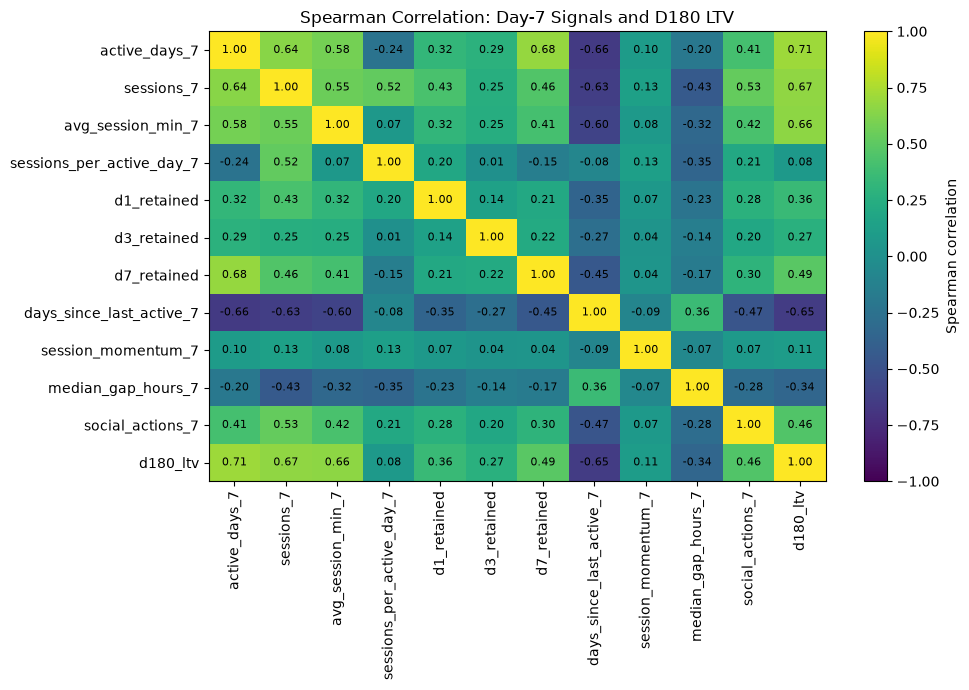

In [38]:
corr = df[common_features + ["d180_ltv"]].corr(method="spearman")

plt.figure(figsize=(10, 7))
im = plt.imshow(corr, aspect="auto", vmin=-1, vmax=1)
plt.colorbar(im, label="Spearman correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)

for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

plt.title("Spearman Correlation: Day-7 Signals and D180 LTV")
plt.tight_layout()
plt.show()


### 6. Campaign-level Day-7 comparison

This is descriptive only. Final campaign evaluation should use predicted D180 LTV and ROAS rather than D7 performance alone.


In [39]:
campaign_eda = df.groupby("campaign").agg(
    users=("user_id", "count"),
    avg_cac=("cac", "mean"),
    avg_active_days_7=("active_days_7", "mean"),
    avg_sessions_7=("sessions_7", "mean"),
    d7_retention=("d7_retained", "mean"),
    actual_d180_ltv=("d180_ltv", "mean")
).reset_index()

campaign_eda["d7_retention"] *= 100
display(campaign_eda)


,campaign,users,avg_cac,avg_active_days_7,avg_sessions_7,d7_retention,actual_d180_ltv
0,Campaign_A,6014,90.0,3.013469,8.113568,13.368806,218.505237
1,Campaign_B,5986,105.0,3.497661,7.895757,22.686268,255.607487


### EDA takeaway

- Retention, recency and frequency provide information beyond raw session counts.
- Subscription has product-specific early monetisation signals: trial and paid conversion.
- Ad-supported has product-specific monetisation signals: impressions, views and rewarded-ad activity.
- Correlation is a screening step; the next step is testing incremental out-of-sample predictive value.
- Because the data is synthetic, these findings validate our assumptions rather than real-world user behaviour.


# ## 4. Select product-specific model features

The model uses only signals observable by Day 7. Campaign and CAC are intentionally excluded from the LTV model and used after prediction for campaign-level ROAS.


In [40]:
def features(data, product):
    """Return the Day-7 features used by the selected product model.

    CAC, campaign, user_id and D180 LTV are deliberately excluded.
    Campaign and CAC are used downstream for campaign economics and ROAS.
    """
    common_features = [
        "active_days_7",
        "sessions_7",
        "avg_session_min_7",
        "sessions_per_active_day_7",
        "d1_retained",
        "d3_retained",
        "d7_retained",
        "days_since_last_active_7",
        "session_momentum_7",
        "median_gap_hours_7",
        "social_actions_7",
    ]

    product_features = (
        ["trial_started_d7", "subscription_started_d7", "days_to_trial"]
        if product == "subscription"
        else [
            "ad_impressions_7",
            "ad_views_7",
            "rewarded_ads_watched_7",
            "ad_view_rate_7",
            "rewarded_ad_rate_7",
        ]
    )

    return data[common_features + product_features]


# ## 5. Compare candidate models and evaluate the selected model

For each product, compare a mean baseline, Linear Regression, Ridge, Random Forest and HistGradientBoosting using 5-fold cross-validation on the training split. Select the model with the lowest mean CV MAE, then evaluate that winner once on the untouched holdout set. MAE, RMSE and R² are regression metrics; R² is not an accuracy measure. Campaign ROAS uses holdout predictions and campaign-level CAC. Because the data is synthetic, performance reflects the generator's assumptions rather than real-world predictive accuracy.

In [41]:
summary = []
metrics = []
model_selection = []
associations = []


def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred),
    }


def make_candidates():
    # days_to_trial is undefined (NaN) for users who did not start a trial.
    # Impute within each CV fold to avoid leakage and support all estimators.
    return {
        "mean_baseline": make_pipeline(
            SimpleImputer(strategy="median"), DummyRegressor(strategy="mean")
        ),
        "linear_regression": make_pipeline(
            SimpleImputer(strategy="median"), LinearRegression()
        ),
        "ridge_regression": make_pipeline(
            SimpleImputer(strategy="median"), Ridge(alpha=1.0)
        ),
        "random_forest": make_pipeline(
            SimpleImputer(strategy="median"),
            RandomForestRegressor(
                n_estimators=200, min_samples_leaf=3, n_jobs=1, random_state=42
            ),
        ),
        "hist_gradient_boosting": make_pipeline(
            SimpleImputer(strategy="median"),
            HistGradientBoostingRegressor(
                max_iter=250, learning_rate=0.05, max_leaf_nodes=15,
                l2_regularization=2, random_state=42
            ),
        ),
    }


for product in ["subscription", "ad_supported"]:
    product_data = df[df["product"] == product].copy()
    X = features(product_data, product)
    y = product_data["d180_ltv"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=42
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)
    candidates = make_candidates()
    candidate_results = []
    scoring = {
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    }
    for model_name, candidate in candidates.items():
        scores = cross_validate(
            candidate, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1
        )
        candidate_results.append({
            "product": product,
            "model": model_name,
            "CV_MAE": -scores["test_mae"].mean(),
            "CV_MAE_std": scores["test_mae"].std(),
            "CV_RMSE": -scores["test_rmse"].mean(),
            "CV_R2": scores["test_r2"].mean(),
        })

    # Choose by the predeclared primary selection metric: mean CV MAE.
    selected = min(candidate_results, key=lambda row: row["CV_MAE"])
    selected_name = selected["model"]
    model_selection.extend(candidate_results)

    # Training-only out-of-fold residuals provide a simple uncertainty range.
    cv_predictions = cross_val_predict(
        candidates[selected_name], X_train, y_train, cv=cv, n_jobs=-1
    )
    residual_quantiles = np.quantile(y_train.to_numpy() - cv_predictions, [0.10, 0.90])

    model = candidates[selected_name].fit(X_train, y_train)
    predictions = model.predict(X_test)
    metrics.append({
        "product": product,
        "model": selected_name,
        "selection_rule": "lowest mean 5-fold CV MAE",
        **regression_metrics(y_test, predictions),
    })

    # Campaign comparisons are computed on held-out users only.
    product_data = product_data.loc[X_test.index].copy()
    product_data["predicted_d180_ltv"] = np.clip(predictions, 0, None)
    product_data["lower_80"] = np.clip(predictions + residual_quantiles[0], 0, None)
    product_data["upper_80"] = np.clip(predictions + residual_quantiles[1], 0, None)

    for campaign in ["Campaign_A", "Campaign_B"]:
        campaign_data = product_data[product_data["campaign"] == campaign]

        if product == "subscription":
            value_proxy = (
                20 * campaign_data["trial_started_d7"].mean()
                + 50 * campaign_data["subscription_started_d7"].mean()
            )
        else:
            value_proxy = (
                0.20 * campaign_data["ad_impressions_7"].mean()
                + 0.35 * campaign_data["ad_views_7"].mean()
            )

        predicted_ltv = campaign_data["predicted_d180_ltv"].mean()
        actual_ltv = campaign_data["d180_ltv"].mean()
        campaign_cac = campaign_data["cac"].iloc[0]
        predicted_revenue = campaign_data["predicted_d180_ltv"].sum()
        actual_revenue = campaign_data["d180_ltv"].sum()
        acquisition_spend = len(campaign_data) * campaign_cac

        summary.append({
            "product": product,
            "campaign": campaign,
            "users": len(campaign_data),
            "campaign_cac": campaign_cac,
            "acquisition_spend": acquisition_spend,
            "d7_value_proxy": value_proxy,
            "predicted_d180_ltv": predicted_ltv,
            "predicted_ltv_lower_80": campaign_data["lower_80"].mean(),
            "predicted_ltv_upper_80": campaign_data["upper_80"].mean(),
            "actual_d180_ltv_synthetic": actual_ltv,
            "predicted_d180_roas": predicted_revenue / acquisition_spend,
            "actual_d180_roas_synthetic": actual_revenue / acquisition_spend,
        })

    for column in X.columns:
        associations.append({
            "product": product,
            "feature": column,
            "spearman_corr_with_d180_ltv": X[column].corr(y, method="spearman"),
        })


# ## 6. Export results

Exports the synthetic feature table, campaign economics for the untouched holdout, cross-validation model comparison, selected-model holdout metrics, and feature associations.

In [42]:
summary_df = pd.DataFrame(summary)
model_selection_df = pd.DataFrame(model_selection)
metrics_df = pd.DataFrame(metrics)
associations_df = pd.DataFrame(associations)

summary_df.to_csv(OUTPUT_DIR / "campaign_summary.csv", index=False)
model_selection_df.to_csv(OUTPUT_DIR / "model_selection_cv_metrics.csv", index=False)
metrics_df.to_csv(OUTPUT_DIR / "selected_model_holdout_metrics.csv", index=False)
associations_df.sort_values(
    ["product", "spearman_corr_with_d180_ltv"], ascending=[True, False]
).to_csv(OUTPUT_DIR / "feature_associations.csv", index=False)

print("Campaign comparison (untouched holdout users)")
print(summary_df.round(2).to_string(index=False))
print("\n5-fold CV model comparison (training split)")
print(model_selection_df.sort_values(["product", "CV_MAE"]).round(3).to_string(index=False))
print("\nSelected model: untouched holdout metrics")
print(metrics_df.round(3).to_string(index=False))

Campaign comparison (untouched holdout users)
     product   campaign  users  campaign_cac  acquisition_spend  d7_value_proxy  predicted_d180_ltv  predicted_ltv_lower_80  predicted_ltv_upper_80  actual_d180_ltv_synthetic  predicted_d180_roas  actual_d180_roas_synthetic
subscription Campaign_A    740          90.0            66600.0           32.35              278.08                  226.65                  329.16                     269.46                 3.09                        2.99
subscription Campaign_B    769         105.0            80745.0           35.21              296.98                  245.41                  348.05                     303.23                 2.83                        2.89
ad_supported Campaign_A    731          90.0            65790.0           13.72              180.41                  150.38                  210.24                     173.74                 2.00                        1.93
ad_supported Campaign_B    761         105.0            79